In [1]:
import sys; print(sys.executable)
import numpy; print(numpy.__version__)

/Users/nechamab/miniconda3/envs/survival/bin/python
2.4.6


# Survival Model Simulation

Comparing three survival models — **Cox Proportional Hazards (CoxPH)**, **Random Survival Forest (RSF)**, and **Gradient Boosting Survival Analysis (GBSA)** — on synthetic data across increasing levels of right-censoring.

The pipeline is split into focused modules under `src/`:

| Module | Responsibility |
|---|---|
| `data_generation.py` | Simulate survival data with controllable censoring |
| `models.py` | Define and configure the three models |
| `evaluation.py` | Compute the evaluation metrics |
| `simulation.py` | Run the experiment loop and aggregate results |
| `plotting.py` | Produce the comparison figures |

## Metrics

- **Harrell's C** — concordance (rank accuracy); ignores the censoring distribution.
- **Uno's C** — IPCW-corrected concordance; robust as censoring grows.
- **Time-dependent AUC** — discrimination across the evaluation horizon.
- **Integrated Brier Score** — calibration + discrimination over time (*lower is better*).

`Actual C` and `Baseline AUC` are oracle values computed from the ground-truth risk scores, included as an upper reference.

In [2]:
import os, sys

# Make the repo root importable whether this notebook is launched from the
# repo root or from notebooks/.
cwd = os.getcwd()
repo_root = cwd if os.path.isdir(os.path.join(cwd, "src")) else os.path.dirname(cwd)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

FIG_DIR = os.path.join(repo_root, "results", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

import pandas as pd
from src.simulation import run_simulation
from src.plotting import (
    plot_model_comparison,
    plot_censoring_performance,
    plot_results,
)
from src.evaluation import METRIC_COLUMNS

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Run the experiment.
# Lower N_REPEATS for a quick run; raise it for smoother error bars.
N_SAMPLES = 500
N_REPEATS = 50

results = run_simulation(
    n_samples=N_SAMPLES,
    m=3,
    n_repeats=N_REPEATS,
    time_points=10,
    random_state=42,
)

## Model comparison

Every metric, all three models, at each censoring level. GBSA leads on AUC and Brier score; the concordance indices are close across models.

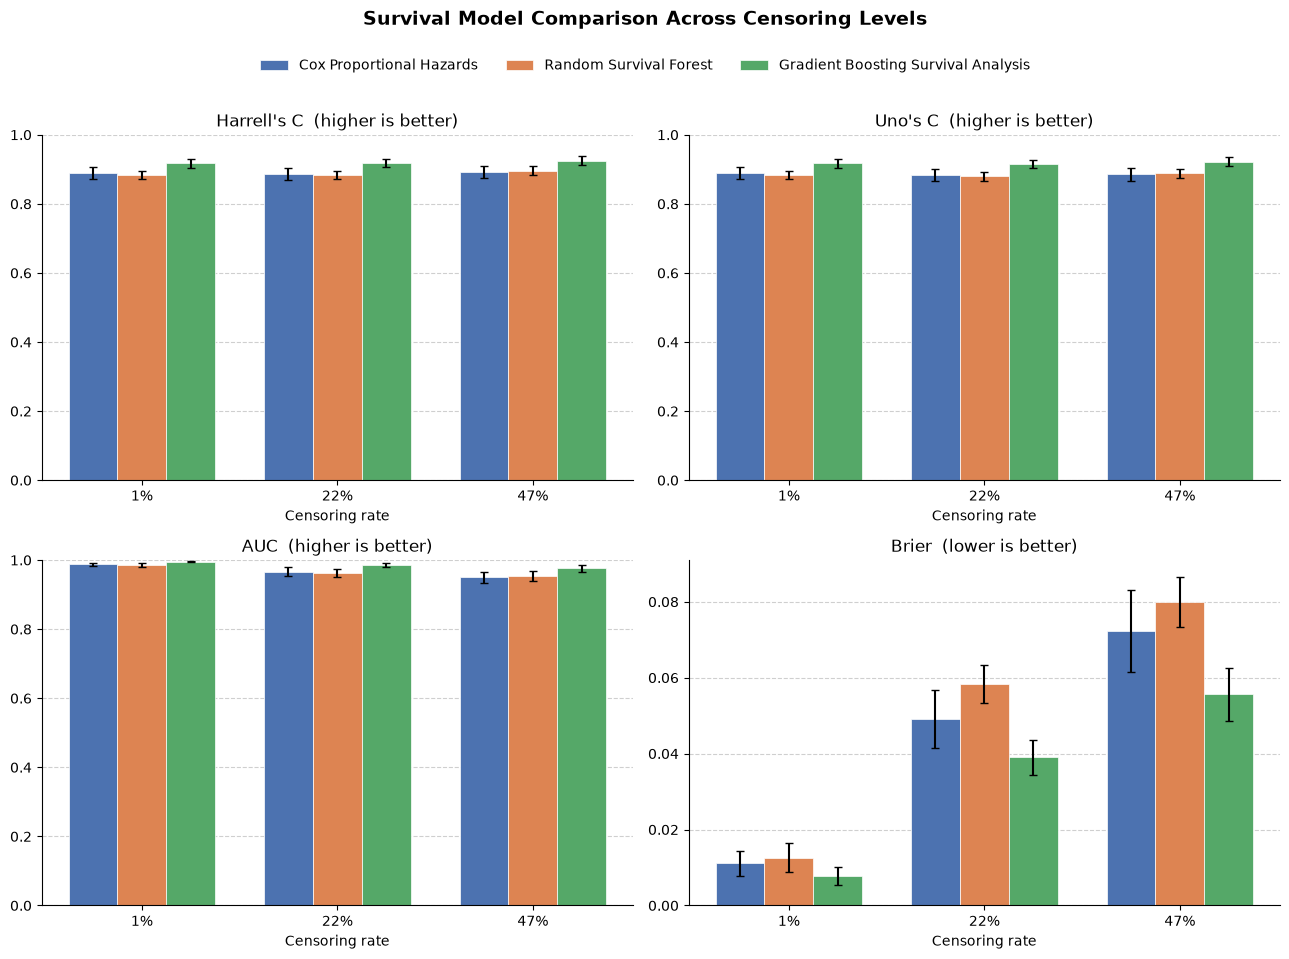

In [4]:
plot_model_comparison(results, save_path=os.path.join(FIG_DIR, "model_comparison.png"));

## Performance vs. censoring

How the headline metrics move as censoring increases. The Brier score makes the degradation clearest — error rises with censoring for every model, and GBSA stays best throughout.

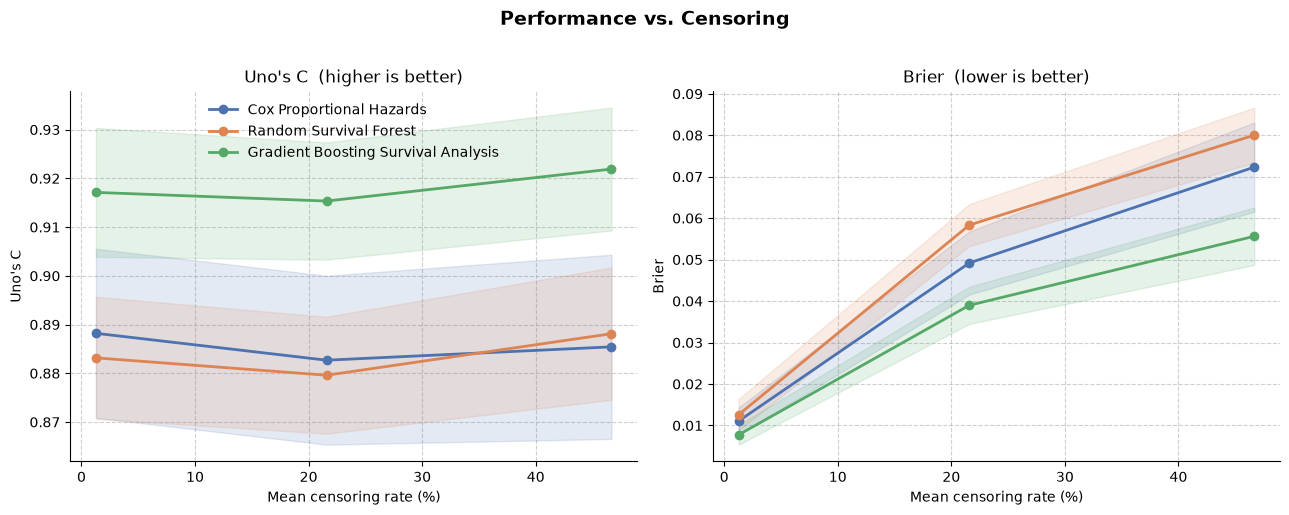

In [5]:
plot_censoring_performance(results, save_path=os.path.join(FIG_DIR, "censoring_performance.png"));

## Per-model detail

A single-model breakdown across censoring levels (swap the model code for `"cph"` or `"rsf"`).

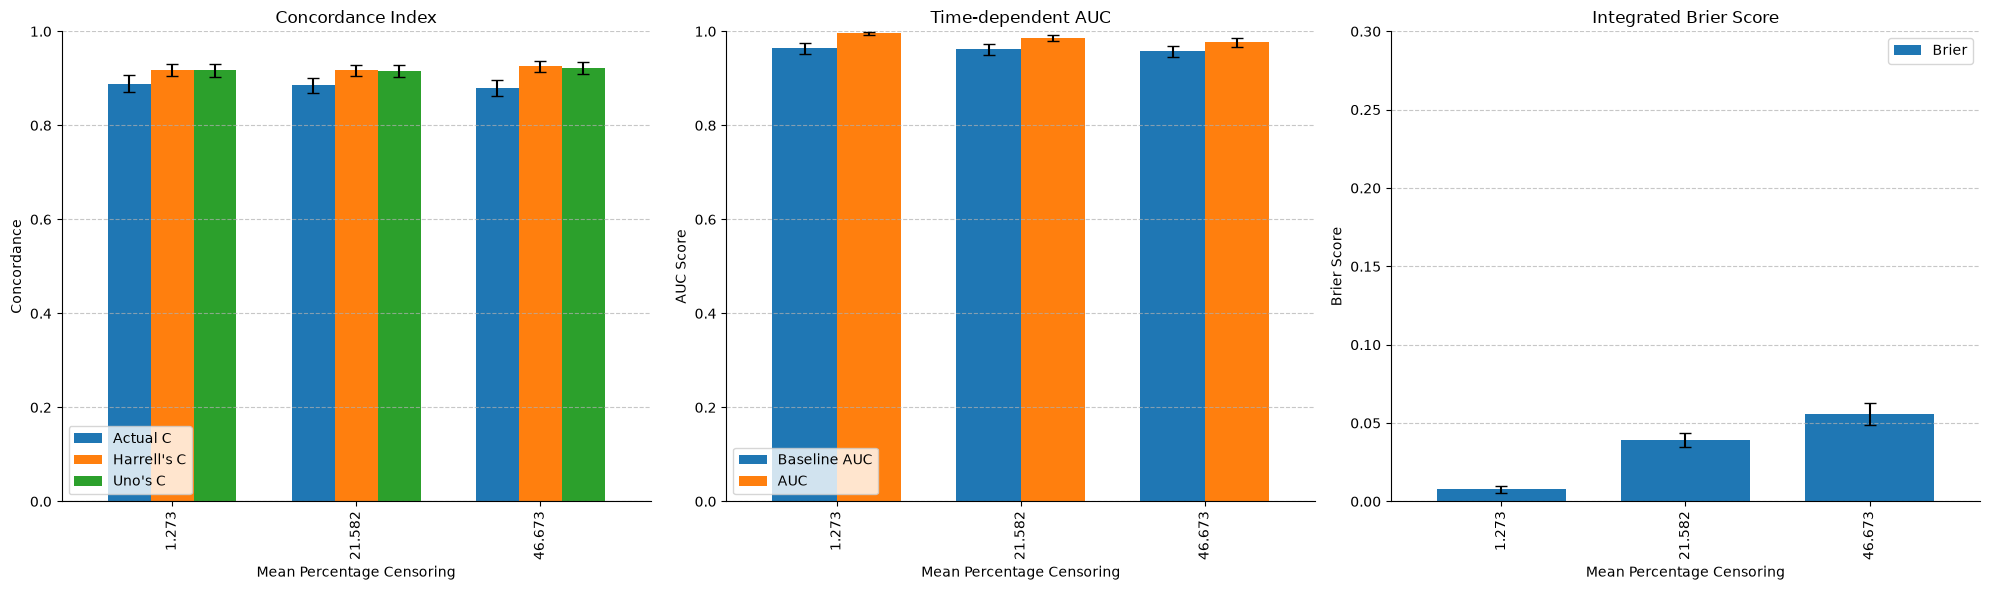

In [6]:
plot_results(results, "gbsa");

## Numeric summary

In [7]:
rows = []
for model_type in results:
    for df in results[model_type]["mean"]:
        row = df.iloc[0].copy()
        row["Model"] = model_type.upper()
        rows.append(row)

summary_df = pd.DataFrame(rows).rename(columns={"censoring": "Censoring %"})
ordered = ["Model", "Censoring %", "Actual C", "Harrell's C",
           "Uno's C", "Baseline AUC", "AUC", "Brier"]
summary_df = summary_df[ordered].round(3).reset_index(drop=True)
summary_df

,Model,Censoring %,Actual C,Harrell's C,Uno's C,Baseline AUC,AUC,Brier
0,CPH,1.273,0.889,0.888,0.888,0.964,0.988,0.011
1,CPH,21.582,0.885,0.886,0.883,0.962,0.966,0.049
2,CPH,46.673,0.879,0.893,0.885,0.957,0.950,0.072
3,RSF,1.273,0.889,0.883,0.883,0.964,0.985,0.013
4,RSF,21.582,0.885,0.884,0.880,0.962,0.962,0.058
5,RSF,46.673,0.879,0.896,0.888,0.957,0.954,0.080
6,GBSA,1.273,0.889,0.917,0.917,0.964,0.996,0.008
7,GBSA,21.582,0.885,0.917,0.915,0.962,0.985,0.039
8,GBSA,46.673,0.879,0.925,0.922,0.957,0.976,0.056
